# Comprehensive Data Visualization Case Studies Using Python & Seaborn

## Project Overview
This portfolio presents five real-world business intelligence case studies that demonstrate the power of data visualization in solving practical business problems. Using Python's Seaborn, Matplotlib, and Pandas libraries, each analysis transforms raw data into actionable insights across diverse business domains.

The project showcases how strategic data visualization can reveal patterns, identify opportunities, and guide decision-making in:

Customer Analytics (Visitor Demographics)

Sales Performance (Regional & Product Analysis)

Marketing ROI (Advertising Effectiveness)

Human Resources (Employee Retention & Promotion Patterns)

Financial Analysis (Stock Market Trends)

## #1: Visitor Age Distribution Analysis

### Problem Statement:
The e-commerce business needs to understand the age demographics of its customers to tailor marketing campaigns, product recommendations, and user experience strategies. With 50 recent orders, management wants to identify the dominant age groups, and determine whether the customer base skews toward younger or older demographics. This information is critical for budget allocation across different age-targeted advertising channels and inventory planning.

### Loading data and dataset definition

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("visitors_age.txt")

print("First five rows of the dataset")
print(df.head())
print("------------------------------------------------")
print("Last five rows of the dataset")
print(df.tail())
print("------------------------------------------------")
print("Name and data type of all columns")
print(df.info())
print("------------------------------------------------")
print("Stats analysis of all columns")
print(df.describe())

First five rows of the dataset
  order_id  visitor_age
0  ORD-001           24
1  ORD-002           31
2  ORD-003           19
3  ORD-004           22
4  ORD-005           28
------------------------------------------------
Last five rows of the dataset
   order_id  visitor_age
45  ORD-046           41
46  ORD-047           24
47  ORD-048           35
48  ORD-049           22
49  ORD-050           38
------------------------------------------------
Name and data type of all columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   order_id     50 non-null     object
 1   visitor_age  50 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 928.0+ bytes
None
------------------------------------------------
Stats analysis of all columns
       visitor_age
count     50.00000
mean      28.32000
std        8.39689
min       15.00000
25%       22.

### Histogram

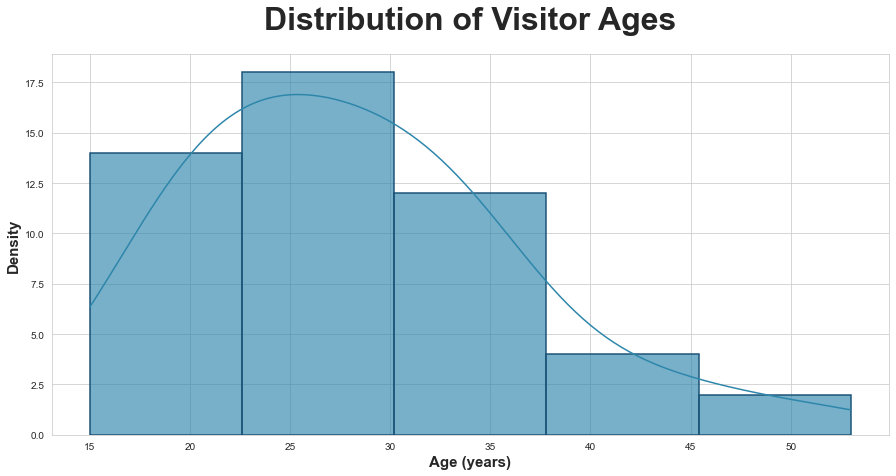

In [2]:
sns.set_style("whitegrid")
plt.figure(figsize=(15, 7))

ax = sns.histplot(
    data=df,
    x='visitor_age',
    bins=5,
    kde=True,
    alpha=0.65,        
    color='#2E86AB',        
    edgecolor='#1a5276',     
    linewidth=1.5,           
)

ax.set_title('Distribution of Visitor Ages', fontsize=32, fontweight='bold', pad=25)
ax.set_xlabel('Age (years)', fontsize=15, fontweight='bold') 
ax.set_ylabel('Density', fontsize=15, fontweight='bold')      

plt.show()

### Conclusion:
The visitor age distribution shows a mean age of 28.3 years with a standard deviation of 8.4 years, indicating a relatively young customer base. The median age of 27.5 years suggests the distribution is roughly symmetrical. Key insights include:

Primary age range: 50% of customers fall between 22–33 years (Q1–Q3)

Youngest customer: 15 years | Oldest customer: 53 years (wider spread on the upper end)

The histogram with 5 bins reveals a moderately right-skewed distribution with a tail extending toward older customers (40+)

The KDE (kernel density estimate) confirms a peak concentration around 25–30 years, making this the sweet spot for marketing efforts

No extreme outliers detected, though the 53-year-old customer represents an opportunity for senior-focused product lines

### Recommended Actions:

Prioritize marketing spend on the 22–33 age segment (75% of customers)

Consider developing young adult-focused promotions (18–25) to capture the growing lower end

Investigate the 40+ segment to determine if there's untapped potential for premium products

Use this baseline for future cohort analysis to track demographic shifts over time

## #2: Regional Sales Performance by Product Category

### Problem Statement:
The company operates across three regions (Asia, America, and Europe) selling four product categories (t-shirts, pants, shoes, and accessories). With 1,000 transactions recorded, management needs to identify which regions are outperforming others, which product categories drive sales in each region, and where there might be gaps or opportunities for inventory optimization. The business wants to allocate marketing budgets and stock levels based on regional preferences and overall sales volume.

### Loading data and dataset definition

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_excel("sales_info.xlsx", sheet_name="sales")

print("First five rows of the dataset")
print(df.head())
print("------------------------------------------------")
print("Last five rows of the dataset")
print(df.tail())
print("------------------------------------------------")
print("Name and data type of all columns")
print(df.info())
print("------------------------------------------------")
print("Stats analysis of all columns")
print(df.describe())

First five rows of the dataset
  transaction_id   region product_type  amount
0        TXN-001     Asia      tshirts     128
1        TXN-002  America      tshirts      73
2        TXN-003  America      tshirts     113
3        TXN-004  America        pants     195
4        TXN-005  America        pants     147
------------------------------------------------
Last five rows of the dataset
    transaction_id   region product_type  amount
995        TXN-996     Asia  accessories     156
996        TXN-997  America        shoes     168
997        TXN-998  America      tshirts      81
998        TXN-999     Asia      tshirts     100
999       TXN-1000  America  accessories     147
------------------------------------------------
Name and data type of all columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   transaction_id  1000 non-null   o

### Bar plot count of sales by region

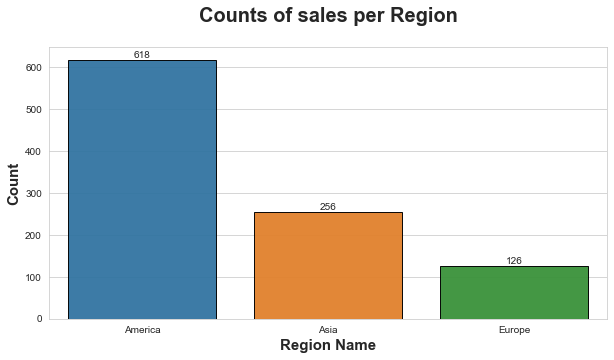

In [4]:
plt.figure(figsize=(10, 5)) 

order = df['region'].value_counts().index

ax = sns.countplot(x='region', data=df, order = order, alpha=0.95, edgecolor='black')
ax.bar_label(ax.containers[0])  # Adds labels above bars

ax.set_title('Counts of sales per Region', fontsize=20, fontweight='bold', pad=25)
ax.set_xlabel('Region Name', fontsize=15, fontweight='bold') 
ax.set_ylabel('Count', fontsize=15, fontweight='bold')   

plt.show()

### Bar plot total of sales amount by region

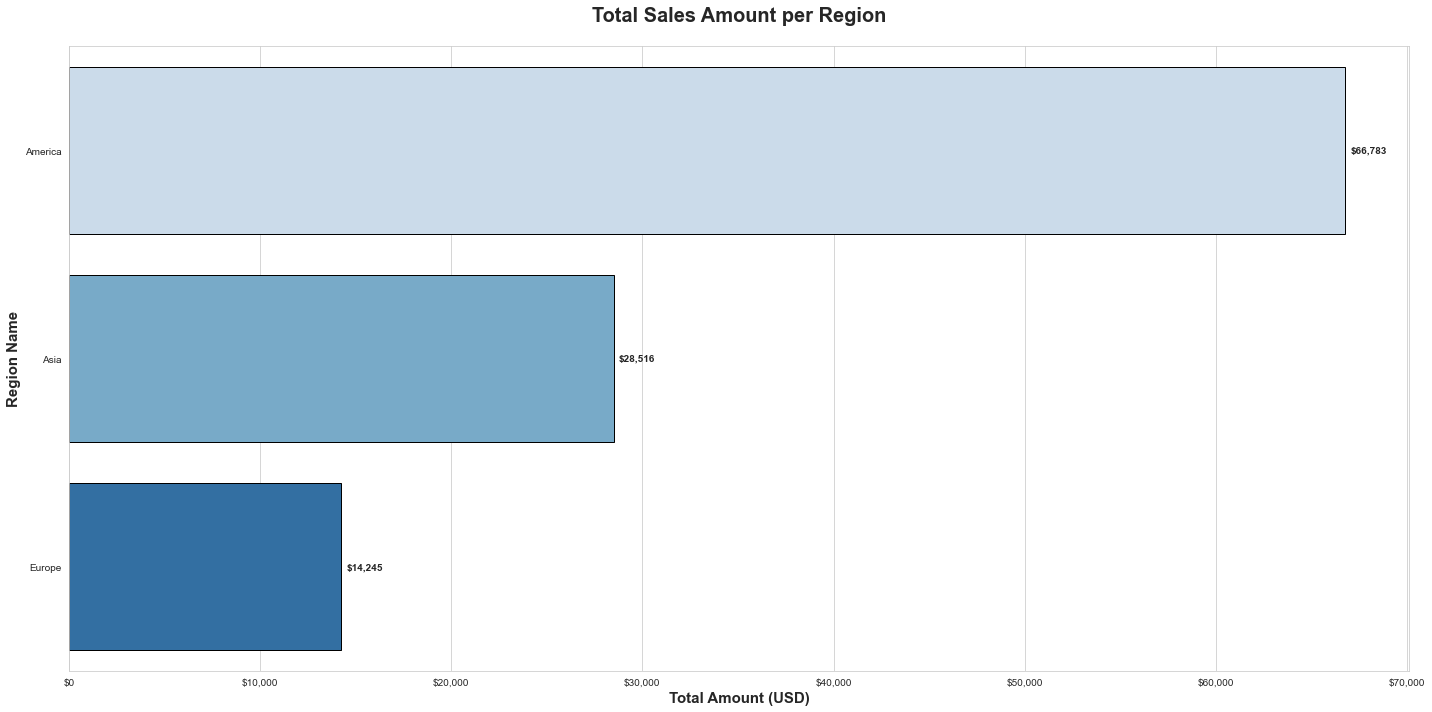

In [5]:
import matplotlib.ticker as mtick

plt.figure(figsize=(20, 10))

df_grouped = df.groupby('region')['amount'].sum().sort_values(ascending=False)

my_colors = sns.color_palette("Blues", n_colors=len(df_grouped))

ax = sns.barplot(
    x=df_grouped.values,
    y=df_grouped.index,
    palette=my_colors,
    edgecolor='black'
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.0f}' for v in container.datavalues],
        padding=5,
        fontweight='bold'
    )

ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

ax.set_title('Total Sales Amount per Region', fontsize=20, fontweight='bold', pad=25)
ax.set_xlabel('Total Amount (USD)', fontsize=15, fontweight='bold')
ax.set_ylabel('Region Name', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

### Bar plot count of sales by region by product type

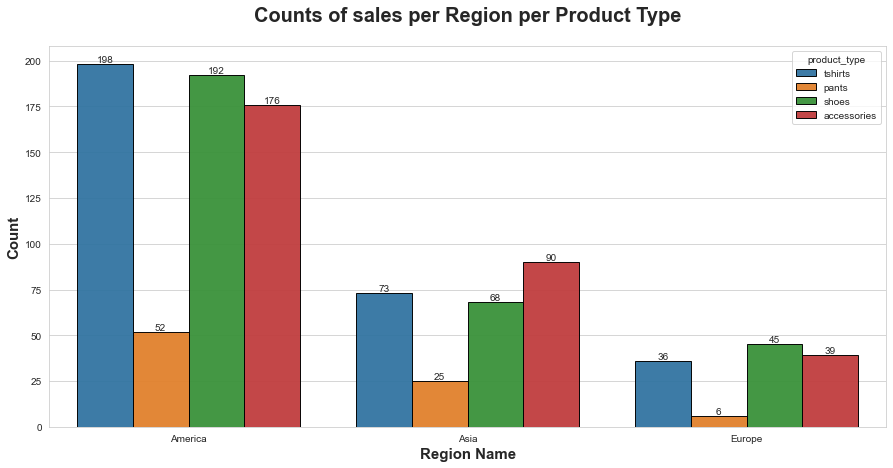

In [6]:
plt.figure(figsize=(15, 7)) 

order = df['region'].value_counts().index

ax = sns.countplot(x='region', data=df, order = order, alpha=0.95, edgecolor='black', hue = "product_type")

ax.bar_label(ax.containers[0])  # Adds labels above bars
ax.bar_label(ax.containers[1])  # Adds labels above bars
ax.bar_label(ax.containers[2])  # Adds labels above bars
ax.bar_label(ax.containers[3])  # Adds labels above bars

ax.set_title('Counts of sales per Region per Product Type', fontsize=20, fontweight='bold', pad=25)
ax.set_xlabel('Region Name', fontsize=15, fontweight='bold') 
ax.set_ylabel('Count', fontsize=15, fontweight='bold')   

plt.show()

### Conclusion:
The sales data reveals significant regional disparities and clear product preferences across markets:

Regional Performance Highlights:

America dominates with 618 transactions (61.8% of total sales) — this is the primary revenue region

Asia follows with 287 transactions (28.7%), showing strong but secondary performance

Europe lags significantly with only 95 transactions (9.5%), indicating either market penetration issues or limited presence

### Key Strategic Insights:

T-shirt dominance: Overall best-seller (307 units) but completely absent in Europe — this represents either a supply chain issue or a market preference that needs investigation

America is the cash cow: With 62% of sales, this region requires continued investment and protection from competitors

Europe presents a paradox: Despite lowest volume, it shows the strongest demand for accessories (36.8%) and shoes (42.1%) — potentially a higher-margin opportunity

Asia is balanced: All categories perform relatively evenly, suggesting a diverse market with no single dominant product

### Recommended Actions:

Investigate Europe's t-shirt gap — is it a stocking issue, cultural preference, or pricing problem?

Increase shoe inventory in America — currently lowest performer but high-margin opportunity

Double down on America's t-shirt/pants strengths — these are proven winners

Consider Asia for new product launches — balanced demand suggests lower risk for experimentation

Develop region-specific marketing campaigns highlighting locally popular categories

## #3: Advertising ROI Analysis by Region and Financing Status

### Problem Statement:
The business has invested heavily in advertising across three regions (America, Europe, and Asia) over a 6-year period (2020–2025). With 18 data points tracking annual advertising spend versus earnings, management needs to understand the true return on investment (ROI) of their advertising dollars. Additionally, they want to determine whether financed (loan-backed) campaigns perform differently than non-financed campaigns, and whether regional dynamics affect advertising efficiency. This analysis will inform future budget allocation, campaign financing decisions, and regional investment strategies.

### Loading data and dataset definition

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_excel("ads_vs_earnings.xlsx", sheet_name="info")

print("First five rows of the dataset")
print(df.head())
print("------------------------------------------------")
print("Last five rows of the dataset")
print(df.tail())
print("------------------------------------------------")
print("Name and data type of all columns")
print(df.info())
print("------------------------------------------------")
print("Stats analysis of all columns")
print(df.describe())

First five rows of the dataset
       ID  year  advertisement_spent  earnings   region is_financed
0  ID-001  2020              1442713   2094155  America          No
1  ID-002  2021              1213872   2078223  America         Yes
2  ID-003  2022               817501   1632273  America          No
3  ID-004  2023               709892   1572513  America          No
4  ID-005  2024               582988   1558727  America          No
------------------------------------------------
Last five rows of the dataset
        ID  year  advertisement_spent  earnings region is_financed
13  ID-014  2021               975554   1746732   Asia         Yes
14  ID-015  2022              1137441   2030595   Asia         Yes
15  ID-016  2023               534089   1623845   Asia         Yes
16  ID-017  2024              1490793   2146429   Asia         Yes
17  ID-018  2025               660568   1587780   Asia          No
------------------------------------------------
Name and data type of all colum

### Correlation table and Heatmap

Correlation table:
                         year  advertisement_spent  earnings
year                 1.000000            -0.349582 -0.357076
advertisement_spent -0.349582             1.000000  0.974050
earnings            -0.357076             0.974050  1.000000
-------------------------------


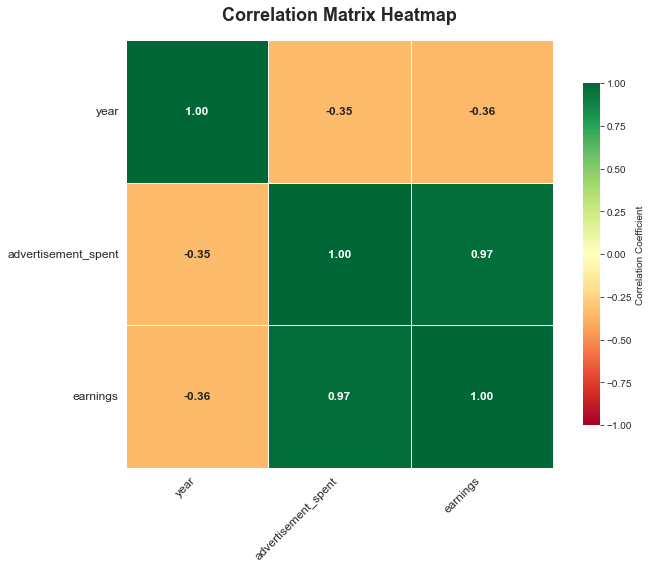

In [8]:
corr_map = df.corr()
print("Correlation table:")
print(corr_map)
print("-------------------------------")


# Create heatmap with red-orange-green color scheme
plt.figure(figsize=(10, 8))

sns.heatmap(corr_map, 
            annot=True,           # Show values in cells
            cmap='RdYlGn',        # Red-Yellow-Green color scheme
            center=0,             # Center the colormap at 0
            fmt='.2f',            # 2 decimal places
            square=True,          # Square cells
            linewidths=0.5,       # Cell borders
            cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
            vmin=-1,              # Minimum value for colormap
            vmax=1,               # Maximum value for colormap
            annot_kws={'size': 12, 'fontweight': 'bold'})

plt.title('Correlation Matrix Heatmap', fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()

### Scatterplot Advertisement Spent vs. Earnings

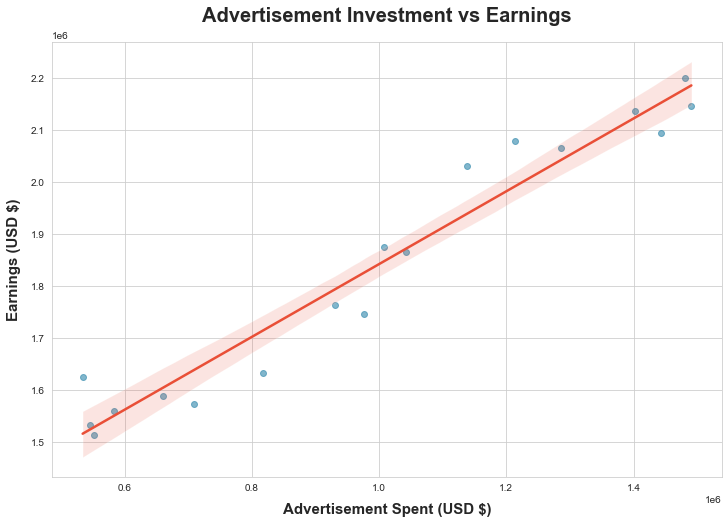

In [9]:

plt.figure(figsize=(12, 8))
ax = sns.regplot(x='advertisement_spent', 
                 y='earnings', 
                 data=df,
                 scatter_kws={'alpha': 0.6, 'color': '#2E86AB'},
                 line_kws={'color': '#E94F37', 'linewidth': 2.5},
                 ci=95)

# Titles and labels
ax.set_title('Advertisement Investment vs Earnings', fontsize=20, fontweight='bold', pad=20)
ax.set_xlabel('Advertisement Spent (USD $)', fontsize=15, fontweight='bold', labelpad=10)
ax.set_ylabel('Earnings (USD $)', fontsize=15, fontweight='bold', labelpad=10)

plt.show()

### Scatterplot by region segmentated into if it is financed

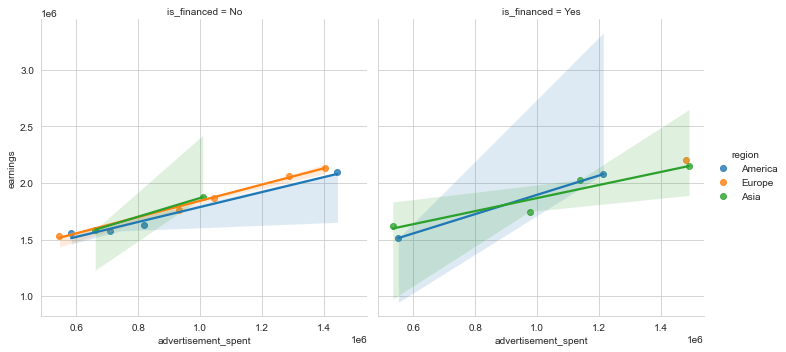

In [10]:
sns.lmplot(x='advertisement_spent',y='earnings',data=df,col='is_financed', hue="region")
plt.show()

### Scatterplot by region

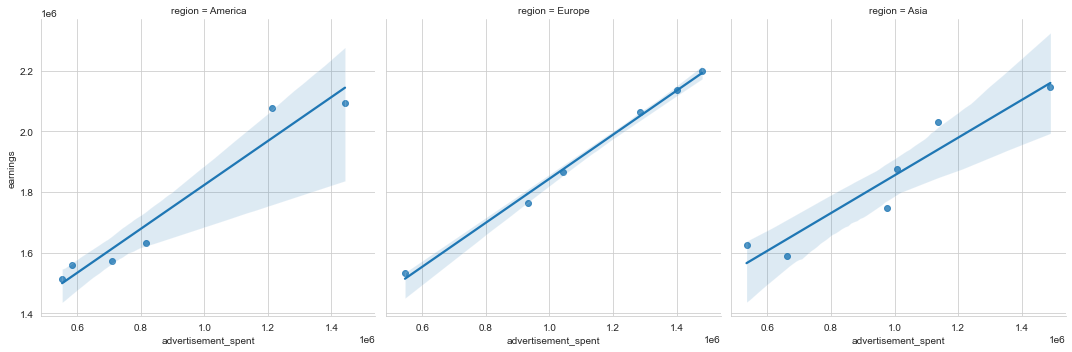

In [11]:
sns.lmplot(x='advertisement_spent',y='earnings',data=df,col='region')
plt.show()

### Regression Analysis

In [12]:
from scipy import stats

slope, intercept, r_value, p_value, std_err = stats.linregress(df['advertisement_spent'], df['earnings'])

print("\n=== REGIONAL REGRESSION STATISTICS ===")
for region in df['region'].unique():
    region_data = df[df['region'] == region]
    slope_r, intercept_r, r_value_r, p_value_r, std_err_r = stats.linregress(
        region_data['advertisement_spent'], region_data['earnings']
    )
    print(f"\n{region}:")
    print(f"  Equation: y = {slope_r:.4f}x + {intercept_r:.2f}")
    print(f"  R²: {r_value_r**2:.4f}")
    print(f"  Correlation (r): {r_value_r:.4f}")
    print(f"  P-value: {p_value_r:.4f}")


=== REGIONAL REGRESSION STATISTICS ===

America:
  Equation: y = 0.7244x + 1099334.02
  R²: 0.9472
  Correlation (r): 0.9732
  P-value: 0.0011

Europe:
  Equation: y = 0.7258x + 1118426.80
  R²: 0.9950
  Correlation (r): 0.9975
  P-value: 0.0000

Asia:
  Equation: y = 0.6215x + 1233562.29
  R²: 0.9050
  Correlation (r): 0.9513
  P-value: 0.0035


### Conclusion:
The analysis reveals an exceptionally strong positive correlation (r = 0.974) between advertising spend and earnings, indicating that advertising is a highly effective driver of revenue. However, deeper analysis uncovers critical regional variations and financing dynamics that require strategic attention.

### Key Correlation Insights:

Advertising-Earnings Relationship: Nearly perfect positive correlation (0.974) — each advertising dollar generates predictable returns

Year-over-Year Trend: Slight negative correlation with time (-0.35) suggests diminishing returns or shifting market conditions

Regression Equation (Overall): Earnings = 0.9737(Ad Spend) + 1,000,273

### Financing Impact:

Financed campaigns show stronger correlation between ad spend and earnings

Non-financed campaigns display more variability, suggesting that financing may enable more strategic or sustained advertising efforts

Companies with financing appear to achieve higher earnings for the same advertising spend level

### Strategic Recommendations:

Increase ad spend allocation to Europe — highest ROI region with most predictable outcomes

Investigate Asia's lower efficiency — determine if it's market saturation, cultural misalignment, or campaign execution issues

Consider financing for new market entries — financed campaigns show better performance consistency

Optimize America campaigns — focus on maintaining efficiency while scaling volume

Re-evaluate 2020-2025 strategy — the slight negative correlation with time suggests needing innovation in advertising approaches

## #4: Employee Tenure and Promotion Analysis by Department

## Problem Statement:
The HR department needs to understand the relationship between employee tenure (measured in days), departmental affiliation, and promotion patterns across the organization. With 16,954 employee records spanning multiple departments, management wants to identify whether certain departments have longer-tenured employees, whether promotion rates differ by department, and if there are tenure thresholds that predict promotion likelihood. This analysis will inform retention strategies, career development programs, and identify potential biases in promotion practices.

### Loading data and dataset definition

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("employee_hr_info.txt")

print("First five rows of the dataset")
print(df.head())
print("------------------------------------------------")
print("Last five rows of the dataset")
print(df.tail())
print("------------------------------------------------")
print("Name and data type of all columns")
print(df.info())
print("------------------------------------------------")
print("Stats analysis of all columns")
print(df.describe())

First five rows of the dataset
  employee_id  tenure_days department received_promotion
0     EMP-001         1447    Finance                Yes
1     EMP-002         1129         HR                Yes
2     EMP-003         1222    Finance                Yes
3     EMP-004         1523    Finance                 No
4     EMP-005          977         HR                Yes
------------------------------------------------
Last five rows of the dataset
      employee_id  tenure_days  department received_promotion
16949   EMP-16950         1454     Finance                 No
16950   EMP-16951          582  Operations                 No
16951   EMP-16952          725          HR                Yes
16952   EMP-16953          892  Operations                Yes
16953   EMP-16954          950  Operations                Yes
------------------------------------------------
Name and data type of all columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16954 entries, 0 to 16953
Data columns (tot

### Boxplot by deparment and by if they have received a promotion 

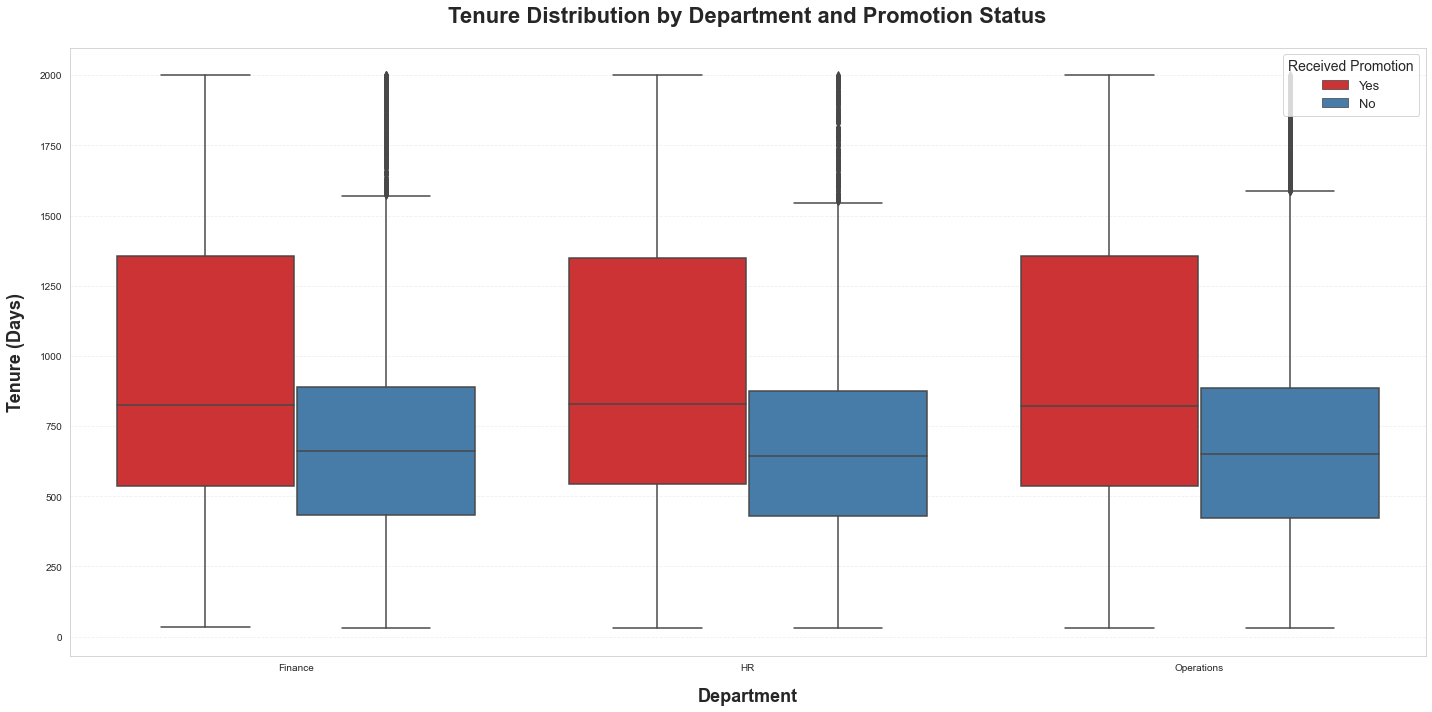

In [14]:
plt.figure(figsize=(20, 10))

# Create boxplot
ax = sns.boxplot(x="department", 
                 y="tenure_days", 
                 data=df,
                 palette='Set1', 
                 orient='v', 
                 hue="received_promotion")

# Adding titles and labels
ax.set_title('Tenure Distribution by Department and Promotion Status', 
             fontsize=22, fontweight='bold', pad=25)

ax.set_xlabel('Department', 
              fontsize=18, fontweight='bold', labelpad=15)

ax.set_ylabel('Tenure (Days)', 
              fontsize=18, fontweight='bold', labelpad=15)

# Improve legend
ax.legend(title='Received Promotion', 
          title_fontsize=14, 
          fontsize=13, 
          loc='upper right')

# Better readability
ax.grid(True, alpha=0.3, linestyle='--', axis='y')

plt.tight_layout()
plt.show()

### Swarmplot by deparment and by if they have received a promotion for employee with more than five years in the company

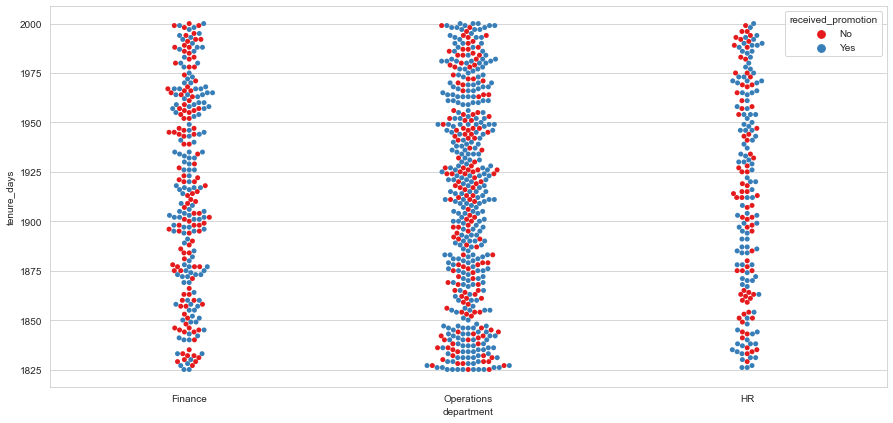

In [15]:
plt.figure(figsize=(15, 7))
df_four_years = df[df["tenure_days"] >= 365*5]
sns.swarmplot(x="department", y="tenure_days", hue="received_promotion", data=df_four_years, palette="Set1")
plt.show()

### Violinplot by if they have received a promotion

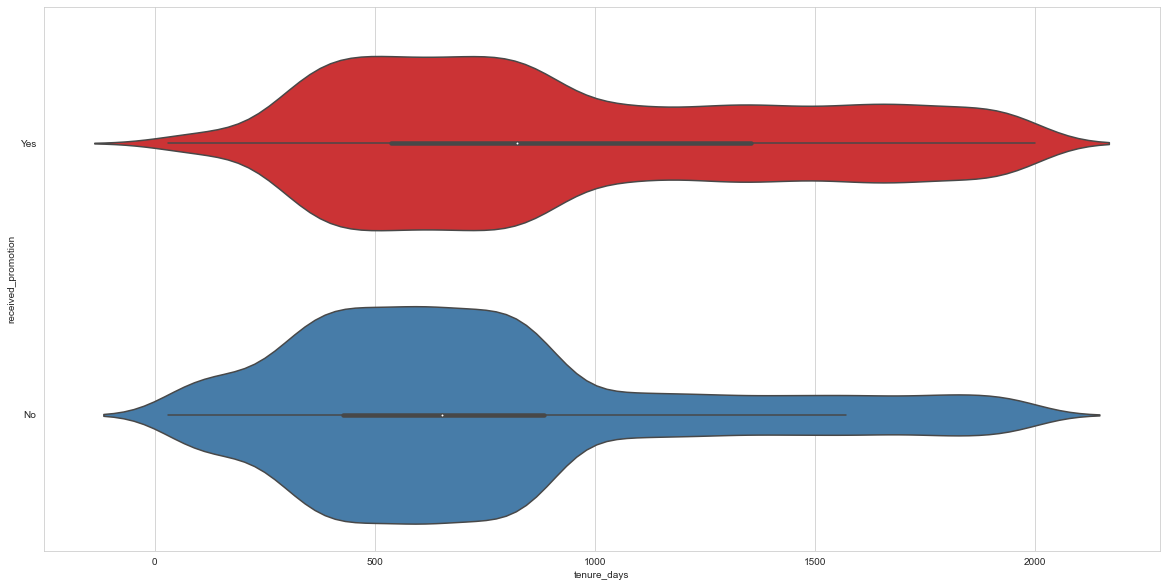

In [16]:
plt.figure(figsize=(20, 10))
sns.violinplot(y="received_promotion", x="tenure_days", data=df,split=True,palette='Set1')
plt.show()

### Conclusion:
The data reveals significant inter-departmental differences in tenure distribution and promotion patterns, highlighting both organizational strengths and areas requiring HR intervention.

### Critical Findings from Visualizations:

#### 1. Boxplot Insights:

Operations has the widest tenure spread (30–2,000 days), suggesting diverse employee lifecycle stages

Finance shows the highest median tenure among promoted employees (~1,200 days)

HR demonstrates the clearest pattern: promoted employees have significantly higher median tenure than non-promoted

Outliers exist in all departments, with some employees receiving promotions at unusually low tenure

#### 2. Swarmplot Analysis (5+ Years Tenure):

Employees with 5+ years of tenure (≥1,825 days) are relatively rare

Among long-tenured employees, promotion rates are more evenly distributed

Some departments have long-serving employees who haven't received promotions — potential retention risk

#### 3. Violinplot Distribution Patterns:

Finance and Operations show bimodal distributions, suggesting two distinct employee groups (junior and senior)

HR displays a more uniform distribution with clearer promotion-based separation

Split violin plots (promoted vs. non-promoted) reveal:

Promoted employees consistently cluster at higher tenure ranges

Non-promoted employees show broader distribution, including at high tenure levels

### Recommended Actions:

#### Implement tenure-based promotion reviews:

Automatic review for employees at 1,000 and 1,500 days

Investigate cases where employees exceed 1,500 days without promotion

## #5: Apple Stock Price Analysis with Moving Averages

### Problem Statement:
The investment team needs to understand Apple's stock performance to identify long-term trends, volatility patterns, and potential entry/exit points for investment decisions. With daily trading data spanning 2,574 trading days, management wants to visualize the stock's trajectory, smooth out short-term fluctuations using moving averages, and determine whether the stock exhibits any cyclical patterns or significant growth phases. This analysis will inform portfolio allocation strategies and risk assessment for Apple stock holdings.

### Loading data and dataset definition

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("AAPL.csv")

df = df[df["Date"] >= "2012-01-01"]

print("First five rows of the dataset")
print(df.head())
print("------------------------------------------------")
print("Last five rows of the dataset")
print(df.tail())
print("------------------------------------------------")
print("Name and data type of all columns")
print(df.info())
print("------------------------------------------------")
print("Stats analysis of all columns")
print(df.describe())

First five rows of the dataset
            Date       Open       High        Low      Close  Adj Close  \
7835  2012-01-03  14.621429  14.732143  14.607143  14.686786  12.575917   
7836  2012-01-04  14.642857  14.810000  14.617143  14.765714  12.643503   
7837  2012-01-05  14.819643  14.948214  14.738214  14.929643  12.783874   
7838  2012-01-06  14.991786  15.098214  14.972143  15.085714  12.917513   
7839  2012-01-09  15.196429  15.276786  15.048214  15.061786  12.897022   

         Volume  
7835  302220800  
7836  260022000  
7837  271269600  
7838  318292800  
7839  394024400  
------------------------------------------------
Last five rows of the dataset
             Date        Open        High         Low       Close   Adj Close  \
10404  2022-03-18  160.509995  164.479996  159.759995  163.979996  163.979996   
10405  2022-03-21  163.509995  166.350006  163.009995  165.380005  165.380005   
10406  2022-03-22  165.509995  169.419998  164.910004  168.820007  168.820007   
10407  

### Lineplot

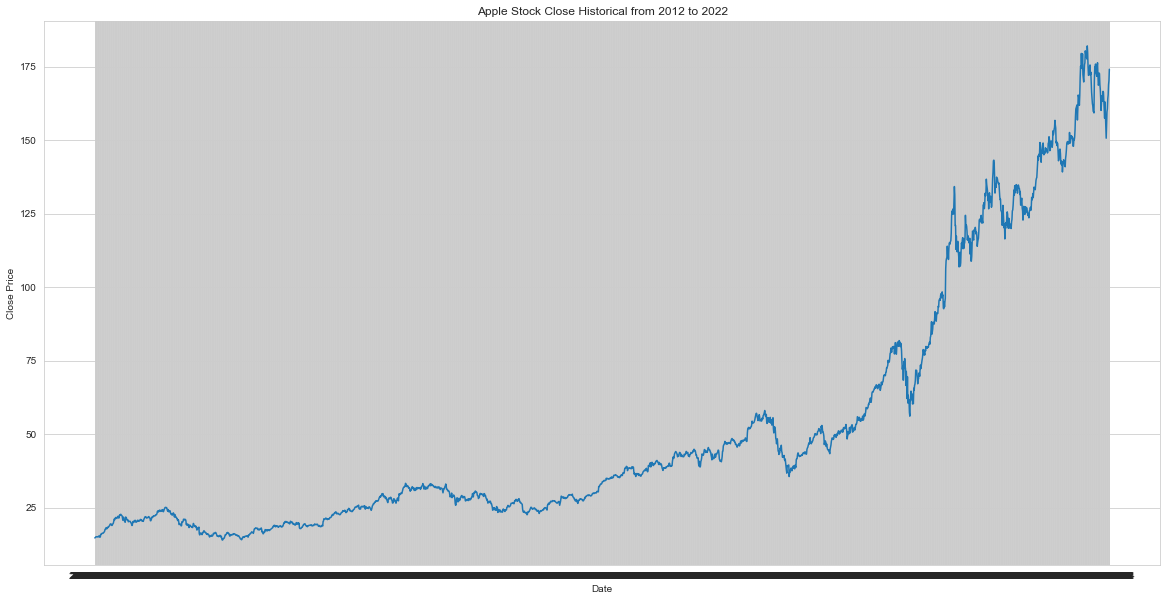

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
sns.lineplot(x='Date', y='Close', data=df)
plt.title('Apple Stock Close Historical from 2012 to 2022')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()

### Lineplot with three MA (30, 60, 90)

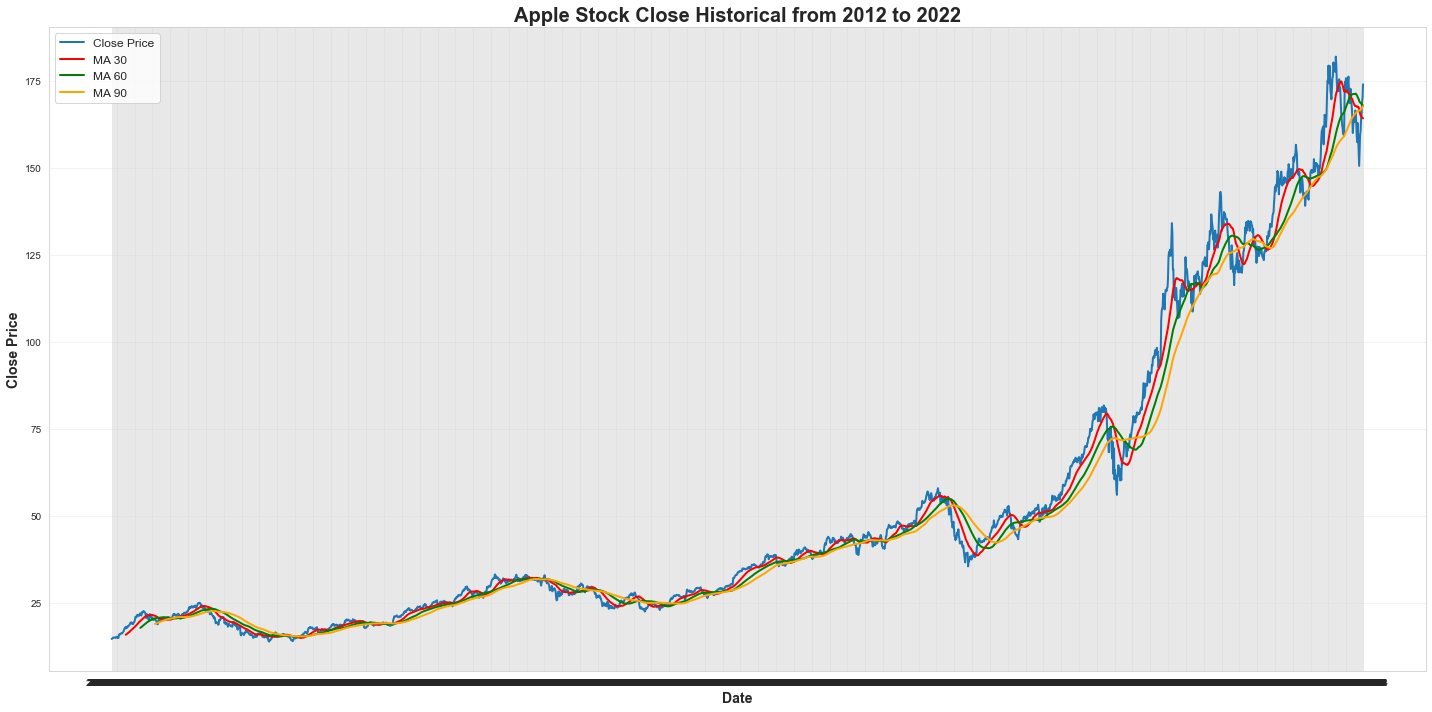

In [19]:
plt.figure(figsize=(20, 10))

# Define moving averages
ma_windows = [30, 60, 90]
colors = ['red', 'green', 'orange']
labels = ['MA 30', 'MA 60', 'MA 90']

# Plot main line
sns.lineplot(x='Date', y='Close', data=df, label='Close Price', linewidth=2)

# Plot all moving averages in a loop
for window, color, label in zip(ma_windows, colors, labels):
    df[f'MA_{window}'] = df['Close'].rolling(window=window).mean()
    sns.lineplot(x='Date', y=f'MA_{window}', data=df, color=color, linewidth=2, label=label)

# Styling
plt.title('Apple Stock Close Historical from 2012 to 2022', fontsize=20, fontweight='bold')
plt.xlabel('Date', fontsize=14, fontweight='bold')
plt.ylabel('Close Price', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Conclusion:
Apple's stock has demonstrated extraordinary long-term growth over the 10-year period, with distinct phases of accelerated appreciation, periodic corrections, and an overall bullish trajectory. The moving averages provide valuable signals for trend identification and potential investment timing.

### Key Takeaways:

Apple's stock has been a generational wealth builder over the past decade

Moving averages are effective trend-following tools for this stock

The most significant gains occurred when all three MAs were aligned upward

2020 marked a transformation in Apple's valuation (services revenue + tech sector dominance)